# PCA Face Identification
$\text{M. Mahdi Mostafaei -- Team 5 (PUFA)}$  

Importing required libraries:

In [1]:
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
import matplotlib.pyplot as plt

## Phase 01: Data Preparation

### Steps 1-3

- Fetching Olivetti dataset and reshaping it
- Seperating train & test dataset (first 8 images for train, last 2 for test)
- Validaitng the seperation result
- Plotting a number of raw data to see what we're gonna deal with


In [2]:
# Load the Olivetti faces dataset
olivetti = fetch_olivetti_faces()
X, y = olivetti.data, olivetti.target

# Reshape to get images per person
# Each person has 10 images, and they're consecutive
images_per_person = 10
n_people = 40

# Reshape to (40 people, 10 images, 4096 features)
X_reshaped = X.reshape(n_people, images_per_person, -1)
y_reshaped = y.reshape(n_people, images_per_person)

# Take first 8 images for training, last 2 for testing
X_train = X_reshaped[:, :8, :].reshape(-1, X.shape[1])
y_train = y_reshaped[:, :8].reshape(-1)

X_test = X_reshaped[:, 8:, :].reshape(-1, X.shape[1])
y_test = y_reshaped[:, 8:].reshape(-1)

# Verify
print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")  # 40 × 8 = 320
print(f"Test samples: {len(X_test)}")      # 40 × 2 = 80
print(f"Training people: {len(np.unique(y_train))}")  # 40
print(f"Test people: {len(np.unique(y_test))}")       # 40

# Check distribution - each person has exactly 8 train, 2 test
print(f"\nImages per person in train: {np.bincount(y_train)}")
print(f"Images per person in test: {np.bincount(y_test)}")

Total samples: 400
Training samples: 320
Test samples: 80
Training people: 40
Test people: 40

Images per person in train: [8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
 8 8 8]
Images per person in test: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2]


Plotting a few of raw data from Olivetti:

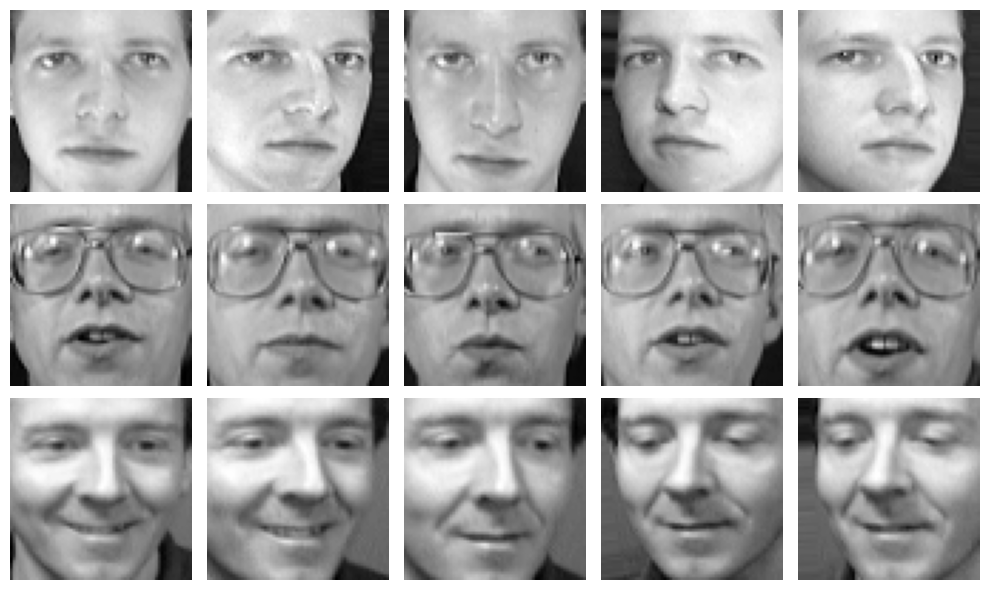

In [3]:
n_persons = 3
images_to_show = 5

fig, axes = plt.subplots(n_persons, images_to_show, figsize=(10, 6))

for person_idx in range(n_persons):
    for img_idx in range(images_to_show):
        # In X_train, each person has exactly 8 images. 
        # So Person 0 is indices 0-7, Person 1 is 8-15, etc.
        row_idx = (person_idx * 8) + img_idx
        
        # Grab the image vector and reshape to 64x64
        img = X_train[row_idx].reshape(64, 64)
        
        # Plot on the corresponding subplot
        ax = axes[person_idx, img_idx]
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        
plt.tight_layout()
plt.show()

### Step 4

Computing the mean $\mu$ and Subtracting it from both $X_{train}$ and $X_{test}$ to make them centered in the feature space:

$\mu = \frac{1}{N} \sum_{i=1}^{N} x_i$

In [4]:
mean_face = X_train.mean(axis=0)

X_train_centered = X_train - mean_face
X_test_centered = X_test - mean_face

Plotting the  `meanface` to see how it looks (Don't do it after midnight!)

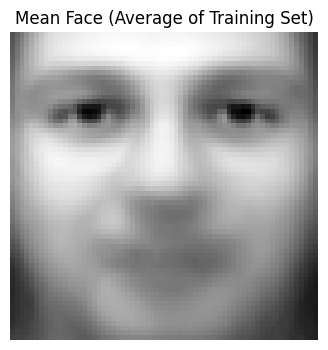

In [5]:
# Plot the Mean Face
plt.figure(figsize=(4, 4))
plt.imshow(mean_face.reshape(64, 64), cmap='gray')
plt.title("Mean Face (Average of Training Set)")
plt.axis('off')
plt.show()

Computing Variance of features to visualize which parts of faces have the most variations in this dataset:

$\sigma^2 = \frac{1}{N-1} \sum_{i=1}^{N} (x_i - \mu)^2$

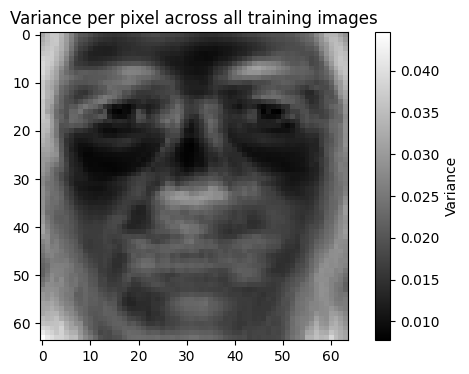

In [6]:
# Compute variance for each feature (pixel)
variances = X_train.var(axis=0)

# Visualize variance heatmap
plt.figure(figsize=(7, 4))
plt.imshow(variances.reshape(64, 64), cmap='grey')
plt.colorbar(label='Variance')
plt.title("Variance per pixel across all training images")
plt.show()

## Phase 02: Learning Subspaces

### Step 5

Making the covariance matrix for the centered $X_{train}$ matrix with $N$ samples (images):

$S = \frac{1}{N-1}X_{c}^T \cdot X_{c}$ 

In [7]:
cov_matrix = (1 / (X_train_centered.shape[0] - 1)) * (X_train_centered.T @ X_train_centered)

Eigendecomposition and sorting them so that $\lambda_1 > \lambda_2 > ... $ and $ v_1 > v_2 > ... $

In [8]:
# 1. Perform eigendecomposition (allowed by project rules)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# 2. Get the indices that would sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]

# 3. Apply the sorting to both eigenvalues and eigenvectors
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

# Verify the shapes (should be 4096 and 4096x4096)
print(f"Eigenvalues shape: {eigenvalues_sorted.shape}")
print(f"Eigenvectors shape: {eigenvectors_sorted.shape}")

Eigenvalues shape: (4096,)
Eigenvectors shape: (4096, 4096)


### Step 6
Reshaping the eigenvectors to $64*64$ matrices and plotting them to see the ***eigenfaces***:

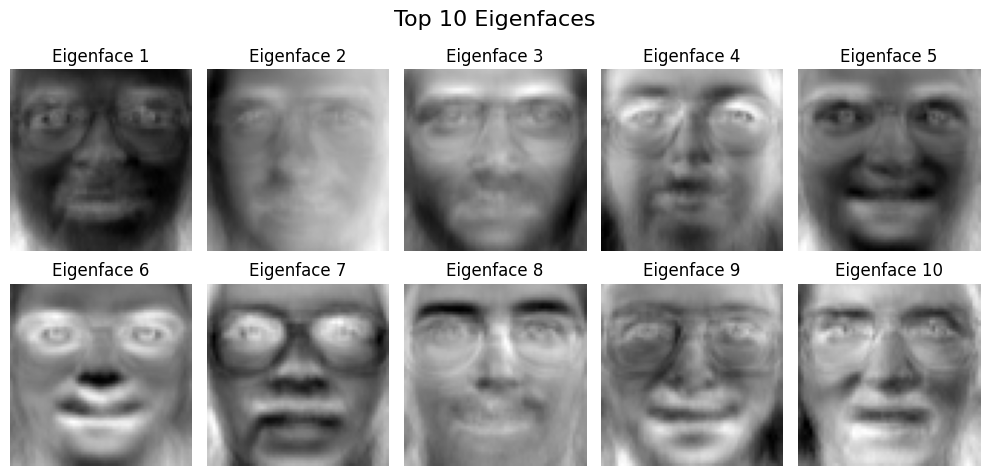

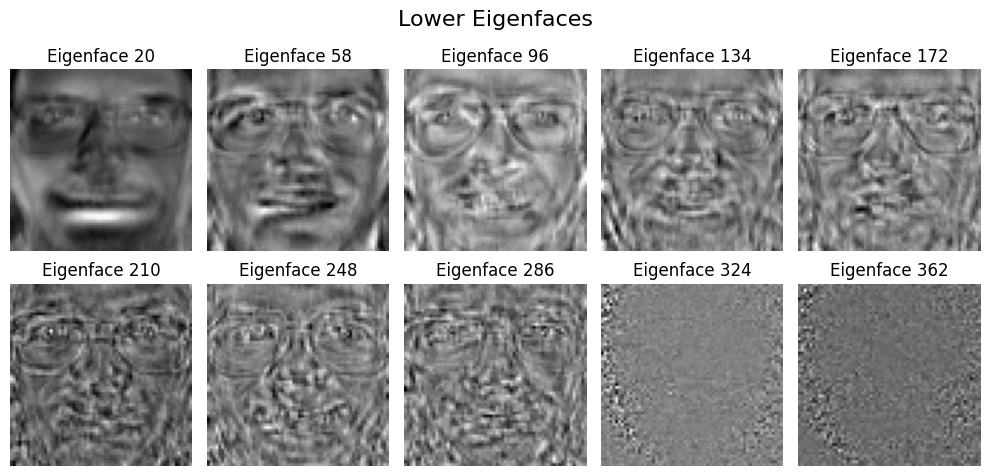

In [9]:
# ==========================================
# 1. Plot Top 12 Eigenfaces (Most Important)
# ==========================================
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
fig.suptitle("Top 10 Eigenfaces", fontsize=16)
axes = axes.flatten()

for i in range(10):
    # Extract the i-th eigenvector
    eigenvector = eigenvectors_sorted[:, i]
    eigenface = eigenvector.reshape(64, 64)
    
    # Plot it (starting at axes[i] instead of axes[i+1])
    axes[i].imshow(eigenface, cmap='gray')
    axes[i].set_title(f"Eigenface {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


# ==========================================
# 2. Plot Eigenfaces 2000 to 3800 (Step 200)
# ==========================================
fig, axes = plt.subplots(2, 5, figsize=(10, 5)) # Slightly wider figsize for 5 columns
fig.suptitle("Lower Eigenfaces", fontsize=16)
axes = axes.flatten()

# Generate the 10 indices: 
indices_to_plot = range(19, 399, 38)

for i, idx in enumerate(indices_to_plot):
    # Extract the eigenvector at the current index
    eigenvector = eigenvectors_sorted[:, idx]
    eigenface = eigenvector.reshape(64, 64)
    
    # Plot it
    axes[i].imshow(eigenface, cmap='gray')
    
    # +1 because humans count from 1, but Python indexes from 0
    axes[i].set_title(f"Eigenface {idx+1}") 
    axes[i].axis('off')


plt.tight_layout()
plt.show()

### Step 7
Reconstructing the image using $k$ eigenvectors. Testing for $k={10, 50, 150}$. the two steps are:

- **Compression:** To find out how much of each "eigenface" is inside a specific image, we calculate a weight vector,<br> as the dot product of mean-centered image vector $X_{c}$ (1, 4096) and the eigenvectors matrix $U_k$ (4096, k):

    $W = X_c \cdot U_k$


- **Reconstruction:** To rebuild a face, We use these weights ($w_1, w_2, \dots, w_k$) as multipliers for our eigenfaces. <br> i.e we take $w_1$ amounts of Eigenface 1, add $w_2$ amounts of Eigenface 2 and so on. Then we add the `mean_face` that was subtracted before:

    $X_{reconstructed} = W \cdot U_{k}^{T} + \text{Mean Face}$



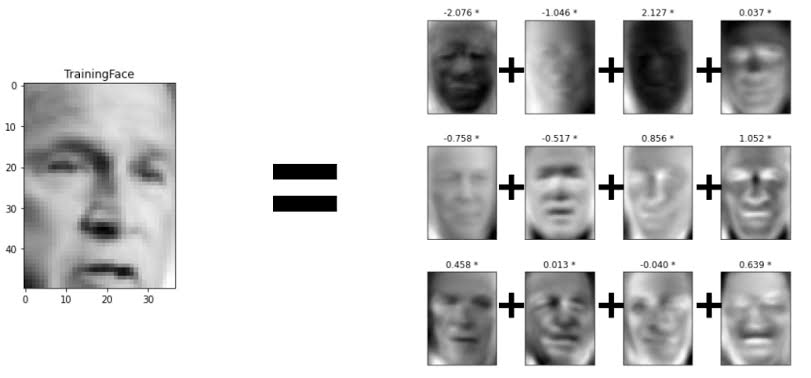

*Reconstruction via Linear Combination.* **Source: GeeksforGeeks**

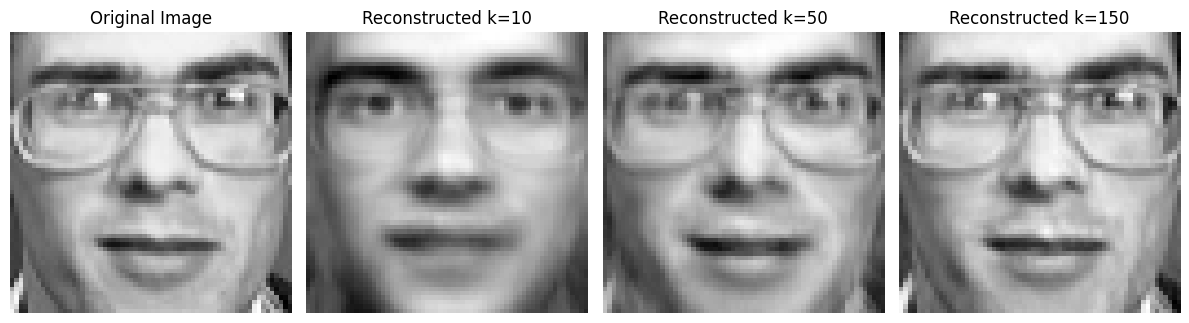

In [10]:
# Choose an image to test
image_idx = 158
original_image = X_train[image_idx]
centered_image = X_train_centered[image_idx]

# Define the k values required by the task instruction
k_values = [10, 50, 150]

# Set up a plot with 1 row and 4 columns (Original + 3 Reconstructions)
fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(12, 4))

# Plot the original image first
axes[0].imshow(original_image.reshape(64, 64), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# Loop through each k value, project, reconstruct, and plot
for i, k in enumerate(k_values):
    # 1. Select the top k eigenvectors
    U_k = eigenvectors_sorted[:, :k]
    
    # 2. Project (Compress): dot product of centered image and U_k
    weights = centered_image @ U_k
    
    # 3. Reconstruct: dot product of weights and U_k.T, then add mean face
    reconstructed_image = (weights @ U_k.T) + mean_face
    
    # 4. Plot the reconstructed image
    axes[i+1].imshow(reconstructed_image.reshape(64, 64), cmap='gray')
    axes[i+1].set_title(f"Reconstructed k={k}")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

## Phase 03: Evaluation & Comparison

### Step 8
 
 ##### **Nearest Neighbor and accuracy**
- Do the **compression** and make a weight matrix $W = X_c \cdot U_k$ for both $X_{train}$ and $X_{test}$ in a k-D space.
- For each test image, compute the **Euclidean distance** from all training images: $\lVert W_{train} - W_{test} \lVert$
- Find the closest train image and predict it as the label
- Compute the accuracy as the ratio of true predictions to all

##### **Reconstruction Error (MSE)**
Reconstruction Error measures how much visual information is lost when you compress an image into a lower-dimensional <br> space and then attempt to rebuild it. This is calculated as a Mean Squared Error (MSE):

$\frac{1}{N} \sum_{i=1}^{N} \left( X_{test} - X_{test \_ reconstructed} \right) ^2$

In [11]:
# Choose a k value
k = 50
U_k = eigenvectors_sorted[:, :k]

# 2. Project both Train and Test data into k-dimensional space
W_train = X_train_centered @ U_k
W_test = X_test_centered @ U_k

# 3. Nearest Neighbor Classification
y_pred = []
for test_vector in W_test:
    # Calculate Euclidean distance between this test vector and all train vectors
    distances = np.linalg.norm(W_train - test_vector, axis=1)
    
    # Find the index of the closest training image
    closest_idx = np.argmin(distances)
    
    # Predict the label of that closest image
    y_pred.append(y_train[closest_idx])

y_pred = np.array(y_pred)

# 4. Calculate and report Accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy (k={k}): {accuracy * 100:.2f}%")

# 5. Calculate Reconstruction Error (Mean Squared Error)
X_test_reconstructed = (W_test @ U_k.T) + mean_face
mse = np.mean((X_test - X_test_reconstructed)**2)
print(f"Reconstruction Error (MSE) (k={k}): {mse:.4f}")

# 6. Find and display ALL failure cases
incorrect_indices = np.where(y_pred != y_test)[0]

if len(incorrect_indices) > 0:
    print(f"\nTotal Failures Found: {len(incorrect_indices)}")
    print("-" * 50)
    for fail_idx in incorrect_indices:
        print(f"Test Index: {fail_idx:2d} | True Identity: {y_test[fail_idx]:2d} | Predicted Identity: {y_pred[fail_idx]:2d}")
else:
    print("\nNo failures found for this k value!")

Test Accuracy (k=50): 88.75%
Reconstruction Error (MSE) (k=50): 0.0037

Total Failures Found: 9
--------------------------------------------------
Test Index:  4 | True Identity:  2 | Predicted Identity: 12
Test Index:  5 | True Identity:  2 | Predicted Identity: 22
Test Index:  7 | True Identity:  3 | Predicted Identity: 12
Test Index:  9 | True Identity:  4 | Predicted Identity: 39
Test Index: 14 | True Identity:  7 | Predicted Identity:  0
Test Index: 17 | True Identity:  8 | Predicted Identity: 39
Test Index: 18 | True Identity:  9 | Predicted Identity: 34
Test Index: 19 | True Identity:  9 | Predicted Identity:  7
Test Index: 30 | True Identity: 15 | Predicted Identity:  0


##### Failure Cases Analysis

**Visual Analysis**

First, visually check what the Nearest Neighbor algorithm saw and what it predicted:

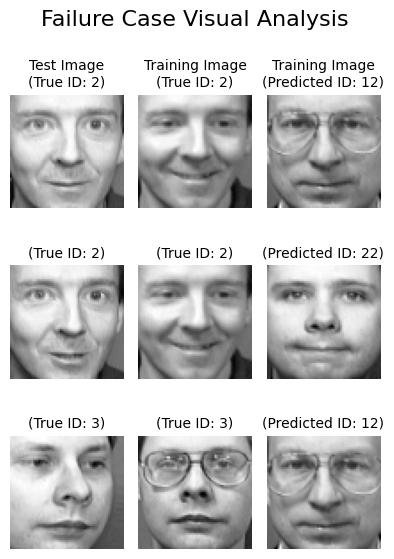

In [12]:
# Take the first 3 failure cases to visualize
cases_to_plot = incorrect_indices[:3]

fig, axes = plt.subplots(len(cases_to_plot), 3, figsize=(4, 2 * len(cases_to_plot)))
fig.suptitle("Failure Case Visual Analysis", fontsize=16)

# You can change this value to control all label sizes at once
label_fontsize = 10 

for i, fail_idx in enumerate(cases_to_plot):
    true_id = y_test[fail_idx]
    pred_id = y_pred[fail_idx]

    # Format the titles: Include the category only if it's the first row (i == 0)
    test_title = f"Test Image\n(True ID: {true_id})" if i == 0 else f"(True ID: {true_id})"
    true_train_title = f"Training Image\n(True ID: {true_id})" if i == 0 else f"(True ID: {true_id})"
    pred_train_title = f"Training Image\n(Predicted ID: {pred_id})" if i == 0 else f"(Predicted ID: {pred_id})"

    # 1. The Test Image (The one the model failed on)
    axes[i, 0].imshow(X_test[fail_idx].reshape(64, 64), cmap='gray')
    axes[i, 0].set_title(test_title, fontsize=label_fontsize)
    axes[i, 0].axis('off')

    # 2. Example of the True Identity from the Training set
    true_train_idx = np.where(y_train == true_id)[0][0]
    axes[i, 1].imshow(X_train[true_train_idx].reshape(64, 64), cmap='gray')
    axes[i, 1].set_title(true_train_title, fontsize=label_fontsize)
    axes[i, 1].axis('off')

    # 3. Example of the incorrectly Predicted Identity
    pred_train_idx = np.where(y_train == pred_id)[0][0]
    axes[i, 2].imshow(X_train[pred_train_idx].reshape(64, 64), cmap='gray')
    axes[i, 2].set_title(pred_train_title, fontsize=label_fontsize)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

**Distance Gap Analysis**

To see exactly how badly the model missed the correct answer:

In [13]:
print("Distance Gap Analysis for Failure Cases:")

# Loop through the incorrect indices you found earlier
for fail_idx in incorrect_indices:
    true_id = y_test[fail_idx]
    
    # 1. Get the compressed test vector for this specific failed image
    test_vector = W_test[fail_idx]
    
    # 2. Calculate Euclidean distances to all training images
    distances = np.linalg.norm(W_train - test_vector, axis=1)
    
    # 3. Sort distances from smallest to largest and get the sorted indices
    sorted_indices = np.argsort(distances)
    
    print(f"\nTest Index {fail_idx:2d} (True ID: {true_id})")
    print("-" * 45)
    
    # Print the top 3 closest matches the model considered
    for rank in range(3):
        match_idx = sorted_indices[rank]
        pred_id = y_train[match_idx]
        dist = distances[match_idx]
        
        # Mark with an 'X' if it's the wrong prediction, or a checkmark if it's right
        marker = "❌" if rank == 0 else "  " 
        print(f"{marker} Rank {rank + 1}: Predicted ID {pred_id:2d} | Distance: {dist:.4f}")
        
    # Find where the TRUE identity actually ranked in the list of distances
    # We look through the sorted training labels to find the first match of the true_id
    true_rank_idx = np.where(y_train[sorted_indices] == true_id)[0][0]
    true_rank = true_rank_idx + 1
    true_dist = distances[sorted_indices[true_rank_idx]]
    
    print(f"👉 The True ID ({true_id}) actually ranked #{true_rank} with a distance of {true_dist:.4f}")

Distance Gap Analysis for Failure Cases:

Test Index  4 (True ID: 2)
---------------------------------------------
❌ Rank 1: Predicted ID 12 | Distance: 5.0063
   Rank 2: Predicted ID 22 | Distance: 5.5729
   Rank 3: Predicted ID  3 | Distance: 5.6940
👉 The True ID (2) actually ranked #12 with a distance of 6.3586

Test Index  5 (True ID: 2)
---------------------------------------------
❌ Rank 1: Predicted ID 22 | Distance: 4.8176
   Rank 2: Predicted ID 22 | Distance: 5.1610
   Rank 3: Predicted ID 12 | Distance: 5.5904
👉 The True ID (2) actually ranked #26 with a distance of 7.0439

Test Index  7 (True ID: 3)
---------------------------------------------
❌ Rank 1: Predicted ID 12 | Distance: 4.5354
   Rank 2: Predicted ID  3 | Distance: 5.3659
   Rank 3: Predicted ID 22 | Distance: 5.6950
👉 The True ID (3) actually ranked #2 with a distance of 5.3659

Test Index  9 (True ID: 4)
---------------------------------------------
❌ Rank 1: Predicted ID 39 | Distance: 4.2987
   Rank 2: Predi

##### Performance Metrics
To sea how *accuracy* and *Reconstruction Error (MSE)* change as $k$ increaes.

Calculating metrics for K=1 to 320. This might take a few seconds...


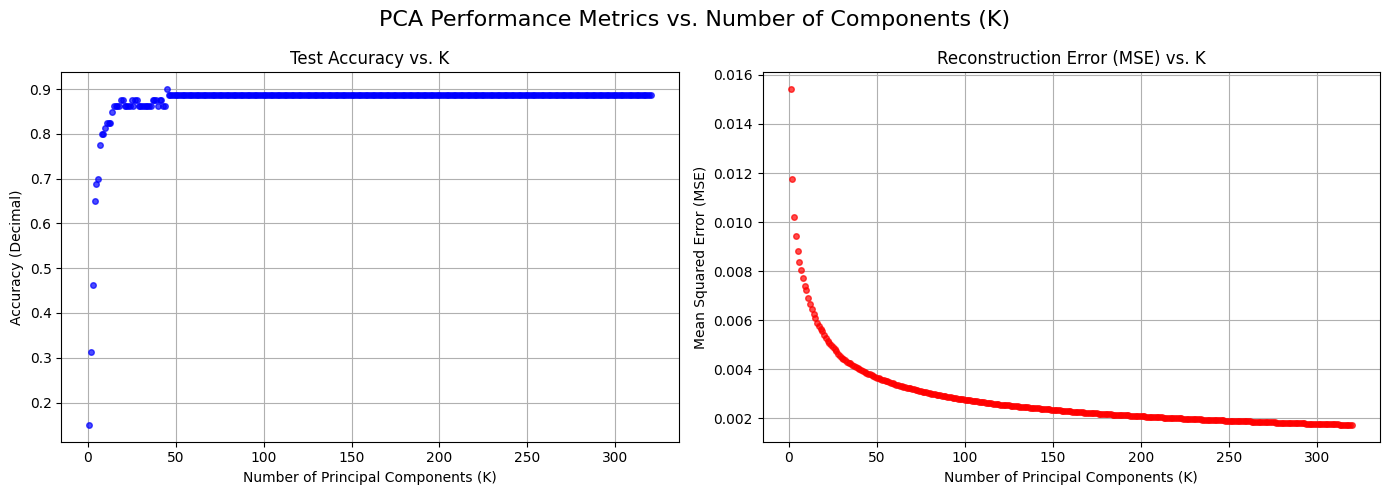

In [16]:

# We want to test K values from 1 up to 320
k_values = range(1, 321)

accuracies = []
reconstruction_errors = []

print("Calculating metrics for K=1 to 320. This might take a few seconds...")

for k in k_values:
    # 1. Slice top k eigenvectors
    U_k = eigenvectors_sorted[:, :k]
    
    # 2. Project Data into k-dimensional space
    W_train = X_train_centered @ U_k
    W_test = X_test_centered @ U_k
    
    # 3. Nearest Neighbor Classification
    y_pred = []
    for test_vector in W_test:
        distances = np.linalg.norm(W_train - test_vector, axis=1)
        closest_idx = np.argmin(distances)
        y_pred.append(y_train[closest_idx])
        
    # 4. Calculate Accuracy
    acc = np.mean(np.array(y_pred) == y_test)
    accuracies.append(acc)
    
    # 5. Calculate Reconstruction Error (MSE)
    X_test_reconstructed = (W_test @ U_k.T) + mean_face
    mse = np.mean((X_test - X_test_reconstructed)**2)
    reconstruction_errors.append(mse)

# ==========================================
# Plotting the Results
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA Performance Metrics vs. Number of Components (K)", fontsize=16)

# Plot 1: Accuracy vs K
ax1.plot(k_values, accuracies, marker='o', linestyle='none', markersize=4, color='blue', alpha=0.7)
ax1.set_title("Test Accuracy vs. K")
ax1.set_xlabel("Number of Principal Components (K)")
ax1.set_ylabel("Accuracy (Decimal)")
ax1.grid(True)


# Plot 2: Reconstruction Error vs K
ax2.plot(k_values, reconstruction_errors, marker='o', linestyle='none', markersize=4, color='red', alpha=0.7)
ax2.set_title("Reconstruction Error (MSE) vs. K")
ax2.set_xlabel("Number of Principal Components (K)")
ax2.set_ylabel("Mean Squared Error (MSE)")
ax2.grid(True)

plt.tight_layout()
plt.show()

### Step 9
Comparison with SVD.
- Use SVD to decompose $X_{train}$ matrix as $X_{train} = U \Sigma V^T$
- Here the matrix $V^T$ is our eigenfaces
- Next steps are the same. Compress, reconstruct, and compute the reconstruction MSE.
- Compare SVD's reconstruction MSE with PCA's reconstruction MSE

In [15]:
# 1. Perform SVD directly on the centered training data
# full_matrices=False is computationally efficient
U, S, Vt = np.linalg.svd(X_train_centered, full_matrices=False)

# 2. Extract the top k components 
# (The rows of Vt are the principal components, so we transpose it)
U_k_svd = Vt.T[:, :k]

# 3. Reconstruct the test data using the SVD components
W_test_svd = X_test_centered @ U_k_svd
X_test_reconstructed_svd = (W_test_svd @ U_k_svd.T) + mean_face

# 4. Compare the Reconstructions (Eigh vs SVD)
# We calculate the Mean Squared Error between the two reconstructed sets
diff = np.mean((X_test_reconstructed - X_test_reconstructed_svd)**2)

print(f"Difference between Eigh and SVD reconstruction: {diff:.10f}")
if diff < 1e-5:
    print("Success! Both methods lead to the same subspace and reconstructions.")

Difference between Eigh and SVD reconstruction: 0.0003075235
